## K-Nearest Neighbors (KNN) Implementation from Scratch

In [41]:
# Content of this cell (Generic Data Definition) has been removed as per user request.

In [42]:
# 2. Define Euclidean Distance Function
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))

# Test the distance function
point_a = np.array([1, 1])
point_b = np.array([6, 6])
print(f"Distance between {point_a} and {point_b}: {euclidean_distance(point_a, point_b):.2f}")

Distance between [1 1] and [6 6]: 7.07


In [43]:
from collections import Counter

# 3. Implement KNN Algorithm
def knn_predict(X_train, y_train, new_point, k):
    distances = []
    for i, train_point in enumerate(X_train):
        dist = euclidean_distance(new_point, train_point)
        distances.append((dist, y_train[i]))

    # Sort by distance and get the k nearest neighbors
    distances.sort(key=lambda x: x[0])
    k_nearest_neighbors = distances[:k]

    # Get the labels of the k nearest neighbors
    neighbor_labels = [label for dist, label in k_nearest_neighbors]

    # Predict the class based on the majority label
    most_common = Counter(neighbor_labels).most_common(1)
    return most_common[0][0]

# The 'k' input for generic data has been removed as per user request.

In [44]:
# Content of this cell (Generic Data KNN Demonstration) has been removed as per user request.

## KNN with Student Data Example

In [45]:
import numpy as np

# Student Data: [Marks, Assignment Marks, Study Hours], Label: Pass/Fail
X_train_student = np.array([
    [85, 90, 10], # Pass
    [78, 85, 8],  # Pass
    [60, 65, 5],  # Fail
    [70, 75, 7],  # Pass
    [55, 60, 4],  # Fail
    [92, 95, 12], # Pass
    [45, 50, 3],  # Fail
    [88, 82, 9]   # Pass
])
y_train_student = np.array([1, 1, 0, 1, 0, 1, 0, 1]) # 1 for Pass, 0 for Fail

print("Student Training Features (X_train_student):\n", X_train_student)
print("Student Training Labels (y_train_student):\n", y_train_student)

Student Training Features (X_train_student):
 [[85 90 10]
 [78 85  8]
 [60 65  5]
 [70 75  7]
 [55 60  4]
 [92 95 12]
 [45 50  3]
 [88 82  9]]
Student Training Labels (y_train_student):
 [1 1 0 1 0 1 0 1]


In [46]:
# 4. Get 'k' from the user for student data
while True:
    try:
        k_student = int(input("Enter the value of k for student data (an integer > 0): "))
        if k_student > 0 and k_student <= len(X_train_student):
            break
        elif k_student > len(X_train_student):
            print(f"k should not be greater than the number of training samples ({len(X_train_student)}). Please try again.")
        else:
            print("k must be a positive integer. Please try again.")
    except ValueError:
        print("Invalid input. Please enter an integer.")

print(f"You entered k = {k_student} for student data")

Enter the value of k for student data (an integer > 0): 8
You entered k = 8 for student data


In [47]:
# 5. Demonstrate the KNN classification with new student data points

student_class_map = {0: 'Fail', 1: 'Pass'}

# New student data point 1: High marks, high study hours
new_student_point_1 = np.array([80, 88, 9])
predicted_student_class_1 = knn_predict(X_train_student, y_train_student, new_student_point_1, k_student)
print(f"\nNew student data point: {new_student_point_1}")
print(f"Predicted outcome for {new_student_point_1} with k={k_student}: {student_class_map[predicted_student_class_1]} (raw label: {predicted_student_class_1})")

# New student data point 2: Low marks, low study hours
new_student_point_2 = np.array([50, 55, 4])
predicted_student_class_2 = knn_predict(X_train_student, y_train_student, new_student_point_2, k_student)
print(f"New student data point: {new_student_point_2}")
print(f"Predicted outcome for {new_student_point_2} with k={k_student}: {student_class_map[predicted_student_class_2]} (raw label: {predicted_student_class_2})")

# New student data point 3: Moderate marks, moderate study hours
new_student_point_3 = np.array([68, 70, 6])
predicted_student_class_3 = knn_predict(X_train_student, y_train_student, new_student_point_3, k_student)
print(f"New student data point: {new_student_point_3}")
print(f"Predicted outcome for {new_student_point_3} with k={k_student}: {student_class_map[predicted_student_class_3]} (raw label: {predicted_student_class_3})")


New student data point: [80 88  9]
Predicted outcome for [80 88  9] with k=8: Pass (raw label: 1)
New student data point: [50 55  4]
Predicted outcome for [50 55  4] with k=8: Pass (raw label: 1)
New student data point: [68 70  6]
Predicted outcome for [68 70  6] with k=8: Pass (raw label: 1)


### Visualizing Student Data

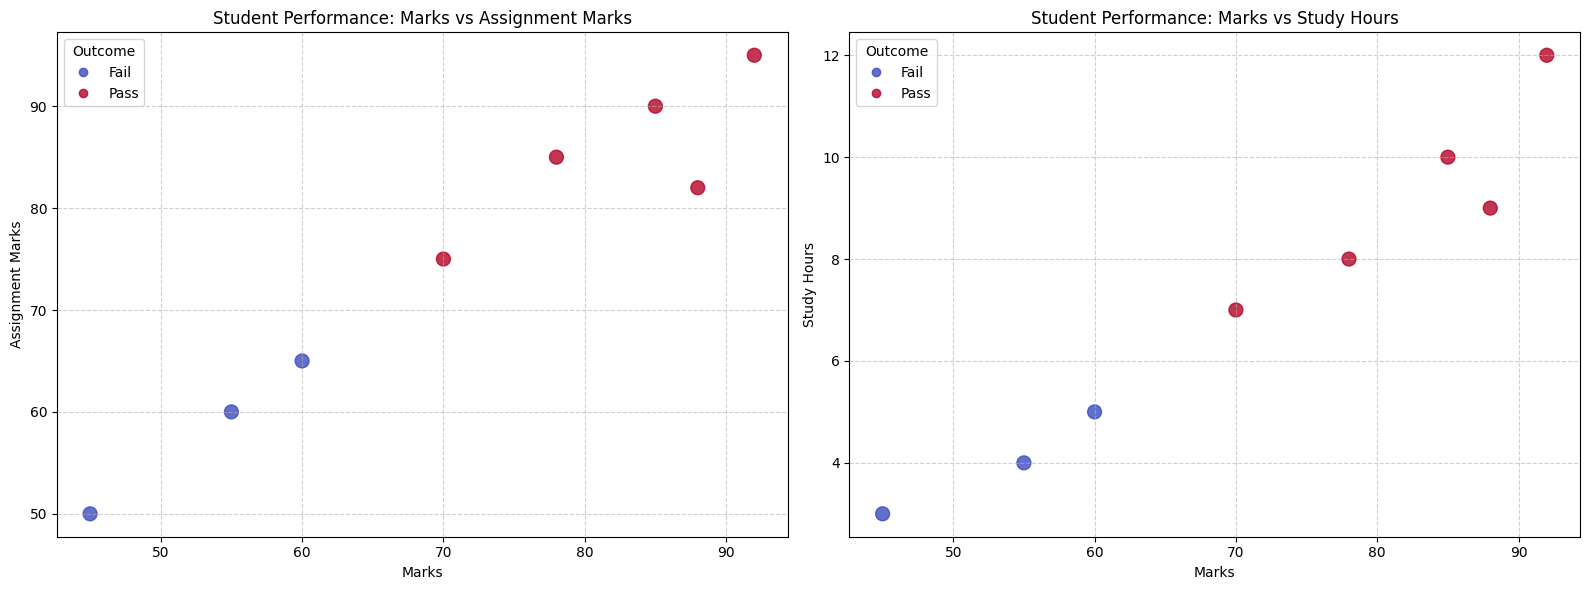

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert student data to a DataFrame for easier plotting
student_df = pd.DataFrame(X_train_student, columns=['Marks', 'Assignment Marks', 'Study Hours'])
student_df['Outcome'] = y_train_student
student_df['Outcome_Label'] = student_df['Outcome'].map({0: 'Fail', 1: 'Pass'})

# Create a figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Marks vs Assignment Marks
scatter1 = axes[0].scatter(student_df['Marks'], student_df['Assignment Marks'], c=student_df['Outcome'], cmap='coolwarm', s=100, alpha=0.8)
axes[0].set_title('Student Performance: Marks vs Assignment Marks')
axes[0].set_xlabel('Marks')
axes[0].set_ylabel('Assignment Marks')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Add legend for the first plot
handles1, labels1 = scatter1.legend_elements()
axes[0].legend(handles=handles1, labels=['Fail', 'Pass'], title='Outcome')

# Plot 2: Marks vs Study Hours
scatter2 = axes[1].scatter(student_df['Marks'], student_df['Study Hours'], c=student_df['Outcome'], cmap='coolwarm', s=100, alpha=0.8)
axes[1].set_title('Student Performance: Marks vs Study Hours')
axes[1].set_xlabel('Marks')
axes[1].set_ylabel('Study Hours')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Add legend for the second plot
handles2, labels2 = scatter2.legend_elements()
axes[1].legend(handles=handles2, labels=['Fail', 'Pass'], title='Outcome')

plt.tight_layout()
plt.show()